In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

df = pd.read_csv('/content/bengaluru_house_prices.csv')

print(df.head())
print(df.info())

              area_type   availability                  location       size  \
0  Super built-up  Area         19-Dec  Electronic City Phase II      2 BHK   
1            Plot  Area  Ready To Move          Chikka Tirupathi  4 Bedroom   
2        Built-up  Area  Ready To Move               Uttarahalli      3 BHK   
3  Super built-up  Area  Ready To Move        Lingadheeranahalli      3 BHK   
4  Super built-up  Area  Ready To Move                  Kothanur      2 BHK   

   society total_sqft  bath  balcony   price  
0  Coomee        1056   2.0      1.0   39.07  
1  Theanmp       2600   5.0      3.0  120.00  
2      NaN       1440   2.0      3.0   62.00  
3  Soiewre       1521   3.0      1.0   95.00  
4      NaN       1200   2.0      1.0   51.00  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   a

In [2]:
print(df.isnull().sum())
print()
print(df.describe())

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

               bath       balcony         price
count  13247.000000  12711.000000  13320.000000
mean       2.692610      1.584376    112.565627
std        1.341458      0.817263    148.971674
min        1.000000      0.000000      8.000000
25%        2.000000      1.000000     50.000000
50%        2.000000      2.000000     72.000000
75%        3.000000      2.000000    120.000000
max       40.000000      3.000000   3600.000000


In [3]:
# Fill missing values
df['location'] = df['location'].fillna(df['location'].mode()[0])
df['size'] = df['size'].fillna(df['size'].mode()[0])
df['bath'] = df['bath'].fillna(df['bath'].median())
df['balcony'] = df['balcony'].fillna(df['balcony'].median())

# Society has many missing values, so drop it
df = df.drop('society', axis=1)

# Convert size to number of bedrooms
df['bhk'] = df['size'].str.extract(r'(\d+)').astype(float)
df = df.drop('size', axis=1)

# Convert total_sqft to numeric
df['total_sqft'] = pd.to_numeric(
    df['total_sqft'].str.extract(r'(\d+\.?\d*)')[0],
    errors='coerce'
)

# Remove rows with invalid total_sqft
df = df.dropna(subset=['total_sqft'])

print(df.isnull().sum())
print(df.shape)

area_type       0
availability    0
location        0
total_sqft      0
bath            0
balcony         0
price           0
bhk             0
dtype: int64
(13320, 8)


In [4]:
# Define features and target
X = df.drop('price', axis=1)
y = df['price']

# One-Hot Encoding for categorical columns
X = pd.get_dummies(
    X,
    columns=['area_type', 'availability', 'location'],
    drop_first=True
)

# Convert boolean columns to integers
X = X.astype(float)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (13320, 1391)
y shape: (13320,)


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (10656, 1391)
X_test: (2664, 1391)
y_train: (10656,)
y_test: (2664,)


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
print("Mean:", X_train_scaled.mean())
print("Std:", X_train_scaled.std())

X_train_scaled shape: (10656, 1391)
X_test_scaled shape: (2664, 1391)
Mean: 6.900499538854079e-19
Std: 0.9622642839266033


In [7]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        89,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,201 (356.25 KB)

 Trainable params: 91,201 (356.25 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 25092.3672 - mae: 78.3816 - val_loss: 23032.1816 - val_mae: 61.9859
Epoch 2/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 14690.5312 - mae: 51.5992 - val_loss: 18405.7617 - val_mae: 47.9760
Epoch 3/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 11608.0664 - mae: 44.2046 - val_loss: 15999.2754 - val_mae: 46.2219
Epoch 4/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 9820.0254 - mae: 40.7926 - val_loss: 14636.3730 - val_mae: 42.0930
Epoch 5/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8665.1738 - mae: 37.9806 - val_loss: 16812.8555 - val_mae: 49.6213
Epoch 6/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8002.3931 - mae: 35.8351 - val_loss: 17795.5371 - val_mae: 51.9479
Epoch 7/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7628.1729 - mae: 35.6703 - val_loss: 29484.3281 - val_mae: 65.2578
Epoch 8/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7356.4277 - mae: 35.0253 - val_loss: 45157.8164 

In [9]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [10]:
model_es = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

model_es.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history_es = model_es.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping]
)

Epoch 1/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 24632.5312 - mae: 77.2320 - val_loss: 23386.0664 - val_mae: 59.5466
Epoch 2/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 14906.7412 - mae: 51.5633 - val_loss: 18606.9453 - val_mae: 50.3421
Epoch 3/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 11601.9658 - mae: 44.5212 - val_loss: 16172.5459 - val_mae: 43.2015
Epoch 4/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 9654.3135 - mae: 39.1887 - val_loss: 14921.5830 - val_mae: 43.6311
Epoch 5/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8488.9629 - mae: 37.4230 - val_loss: 15735.0234 - val_mae: 47.8355
Epoch 6/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7836.8975 - mae: 35.8314 - val_loss: 19877.2891 - val_mae: 55.4199
Epoch 7/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7573.7075 - mae: 35.6705 - val_loss: 33152.5742 - val_mae: 68.8107
Epoch 8/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7310.6909 - mae: 34.7784 - val_loss: 47710.6133

In [11]:
test_loss_es, test_mae_es = model_es.evaluate(
    X_test_scaled,
    y_test
)

print("Early Stopping Test MSE:", test_loss_es)
print("Early Stopping Test MAE:", test_mae_es)

84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 11387.9492 - mae: 45.2999
Early Stopping Test MSE: 11387.94921875
Early Stopping Test MAE: 45.299869537353516


In [12]:
model_dropout = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1)
])

model_dropout.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history_dropout = model_dropout.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping]
)

Epoch 1/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 24799.2695 - mae: 80.5263 - val_loss: 23914.5371 - val_mae: 62.4295
Epoch 2/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 16131.3145 - mae: 53.9110 - val_loss: 19456.1582 - val_mae: 50.0455
Epoch 3/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 12882.9336 - mae: 48.1793 - val_loss: 16727.1738 - val_mae: 45.6312
Epoch 4/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 11207.9258 - mae: 45.2067 - val_loss: 15694.7383 - val_mae: 42.8603
Epoch 5/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 10067.8184 - mae: 42.9365 - val_loss: 15684.7588 - val_mae: 45.4881


In [13]:
test_loss_dropout, test_mae_dropout = model_dropout.evaluate(
    X_test_scaled,
    y_test
)

print("Dropout Test MSE:", test_loss_dropout)
print("Dropout Test MAE:", test_mae_dropout)

84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 17955.5605 - mae: 58.7100
Dropout Test MSE: 17955.560546875
Dropout Test MAE: 58.709999084472656


In [14]:
dropout_mse = test_loss_dropout
dropout_mae = test_mae_dropout

In [15]:
model_lr = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

model_lr.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='mse',
    metrics=['mae']
)

history_lr = model_lr.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping]
)

Epoch 1/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 29415.7559 - mae: 92.0978 - val_loss: 27511.8242 - val_mae: 64.7133
Epoch 2/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 17513.5781 - mae: 57.8503 - val_loss: 22867.2168 - val_mae: 57.6153
Epoch 3/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 14114.9668 - mae: 48.5392 - val_loss: 20402.5215 - val_mae: 52.0767
Epoch 4/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 12244.8750 - mae: 44.3791 - val_loss: 18685.3652 - val_mae: 48.4587
Epoch 5/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 10924.6992 - mae: 41.7829 - val_loss: 17292.7773 - val_mae: 45.6868


In [16]:
test_loss_lr, test_mae_lr = model_lr.evaluate(
    X_test_scaled,
    y_test
)

print("Learning Rate Test MSE:", test_loss_lr)
print("Learning Rate Test MAE:", test_mae_lr)

84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 20388.2637 - mae: 59.7596
Learning Rate Test MSE: 20388.263671875
Learning Rate Test MAE: 59.75962448120117


In [18]:
baseline_mse, baseline_mae = model.evaluate(X_test_scaled, y_test)

results = {
    "Baseline": [baseline_mse, baseline_mae],
    "Early Stopping": [test_loss_es, test_mae_es],
    "Dropout": [test_loss_dropout, test_mae_dropout],
    "Learning Rate 0.0005": [test_loss_lr, test_mae_lr]
}

comparison = pd.DataFrame(
    results,
    index=["MSE", "MAE"]
).T

print(comparison)

84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 858465.1250 - mae: 125.4442
                                MSE         MAE
Baseline              858465.125000  125.444244
Early Stopping         11387.949219   45.299870
Dropout                17955.560547   58.709999
Learning Rate 0.0005   20388.263672   59.759624


In [19]:
# Predictions using the best model
y_pred = model_es.predict(X_test_scaled)

# Compare actual vs predicted prices
comparison_df = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred.flatten()
})

print(comparison_df.head(10))

84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
   Actual Price  Predicted Price
0          64.8        29.202532
1         125.0        89.219437
2          60.0        83.533546
3         110.0       145.191513
4         210.0       170.792023
5          90.0        90.365013
6          65.0        44.339649
7          35.0        39.036964
8          48.0       191.971466
9          49.0        50.389545


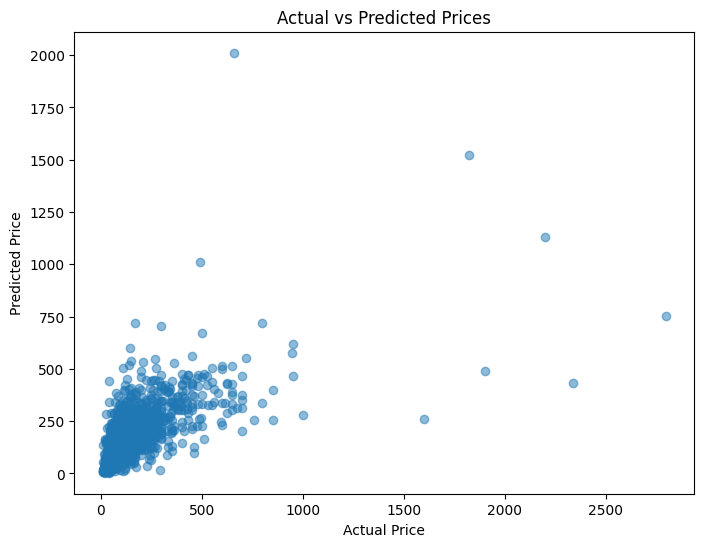

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()